[Apri il notebook originale su Google Colab](https://colab.research.google.com/drive/1_gSyQoyvF3bCWyOVNpXpM825taTrk0b_)

#Data Augmentation per la sicurezza delle centrali elettriche

**CyberEye Solutions**, un leader emergente nel settore della sicurezza cibernetica per infrastrutture critiche, si trova di fronte a una crescente sfida nella protezione delle centrali elettriche contro minacce informatiche avanzate. Attualmente, il sistema di sorveglianza delle centrali utilizza tecnologie di riconoscimento di immagini per identificare e reagire tempestivamente a situazioni potenzialmente pericolose. Tuttavia, la capacità di riconoscere con precisione e tempestività oggetti e comportamenti critici nelle immagini è limitata dai dataset di addestramento attualmente disponibili, che non rappresentano appieno la variabilità e la complessità delle situazioni reali.

Attualmente, i modelli esistenti basati su dataset limitati non riescono a rilevare con la necessaria precisione anomalie o minacce potenziali nelle immagini, compromettendo la capacità di risposta e mitigazione dell'azienda di fronte a situazioni di emergenza. Migliorare la capacità di identificare tempestivamente oggetti e comportamenti critici nelle immagini è fondamentale per garantire la continuità operativa e la sicurezza delle infrastrutture critiche gestite da CyberEye Solutions.

**Benefici della Soluzione**
1. **Miglioramento della Sicurezza delle Infrastrutture Critiche**: Espandere il dataset utilizzando tecniche avanzate di Data Augmentation consentirà di migliorare l'accuratezza del sistema di riconoscimento di immagini. Un modello più preciso e affidabile sarà in grado di rilevare con maggiore tempestività e precisione comportamenti sospetti o minacce potenziali nelle immagini delle centrali elettriche, migliorando così la sicurezza delle infrastrutture critiche e riducendo il rischio di incidenti o sabotaggi.
2. **Efficienza Operativa e Riduzione del Tempo di Risposta**: Automatizzando il processo di generazione di nuovi dati attraverso la creazione di immagini e testi variati, CyberEye Solutions ottimizzerà l'efficienza operativa. Questo permetterà all'azienda di concentrare le risorse umane su attività di analisi e mitigazione delle minacce, riducendo il tempo di risposta agli eventi critici e migliorando la capacità di gestione delle emergenze.
3. **Innovazione Tecnologica nel Settore della Sicurezza**: Utilizzando tecniche avanzate di deep learning e generazione di dati, CyberEye Solutions promuoverà l'innovazione nel campo della sicurezza cibernetica per infrastrutture critiche. L'implementazione di modelli di riconoscimento di immagini più sofisticati non solo migliorerà la sicurezza delle centrali elettriche, ma dimostrerà anche l'impegno dell'azienda nell'adozione di tecnologie all'avanguardia per affrontare le sfide emergenti nel settore della sicurezza cibernetica.

**Dettagli del Progetto**

* **Acquisizione del Dataset**: Utilizzare il dataset **OxfordIIITPet** da PyTorch come base per il progetto di miglioramento del sistema di riconoscimento di immagini per infrastrutture critiche.

* **Image Captioning e Generazione di Dati**: Applicare l’image captioning per creare descrizioni iniziali delle immagini. Successivamente, utilizzare un modello generativo di testo per produrre varianti o descrizioni analoghe. Infine, impiegare un modello generativo di immagini per creare nuove immagini a partire dalle caption originali o dai testi generati, arricchendo così il dataset con dati sintetici.

* **Addestramento del Modello** : Addestrare un modello di riconoscimento di immagini utilizzando il dataset esteso, valutando la qualità dei dati prodotti e confrontando le performance del modello su dataset ridotto e dataset incrementato.

* **Valutazione delle Performance**: Misurare l'accuracy, precision, recall e altre metriche di performance per confrontare il modello addestrato su entrambi i dataset. Commentare le differenze nelle performance e l'efficacia delle tecniche di Data Augmentation nel migliorare l'accuratezza del modello in contesti reali di sicurezza delle infrastrutture critiche.


**Conclusioni**

CyberEye Solutions si impegna a rafforzare la sicurezza delle infrastrutture critiche attraverso l'implementazione di soluzioni avanzate di riconoscimento di immagini. Utilizzando approcci innovativi e tecnologie all'avanguardia, l'azienda mira non solo a migliorare l'efficacia dei suoi sistemi di sicurezza cibernetica, ma anche a definire nuovi standard nel settore per la protezione delle infrastrutture critiche contro le minacce informatiche sempre più sofisticate.

In [ ]:
# Codice originale senza output
# ...

Settiamo i random.

In [ ]:
# Codice originale senza output
# ...

Predisponiamo il device per valutare se sono presenti GPU da poter utilizzare per il training.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Montiamo Google drive

In [ ]:
# Codice originale senza output
# ...

Mounted at /content/drive


##OxfordIIITPet

Il dataset di riferimento OxfordIIITPet è composto da 37 categorie di animali domestici (cani e gatti) con 200 immagini ciascune. Le immagini sono divise per razze:
ES. Abyssinian, Bengal, Beagle, Yorkshire Terrier

In [ ]:
# trasformazione basica
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

In [ ]:
# Load the dataset
oxford_dataset = torchvision.datasets.OxfordIIITPet(root='./data', split='trainval', download=True, transform=transform)
oxford_dataset_test = torchvision.datasets.OxfordIIITPet(root='./data', split='test', download=True, transform=transform)

Classi dataset.

In [ ]:
# Codice originale senza output
# ...

['Abyssinian',
 'American Bulldog',
 'American Pit Bull Terrier',
 'Basset Hound',
 'Beagle',
 'Bengal',
 'Birman',
 'Bombay',
 'Boxer',
 'British Shorthair',
 'Chihuahua',
 'Egyptian Mau',
 'English Cocker Spaniel',
 'English Setter',
 'German Shorthaired',
 'Great Pyrenees',
 'Havanese',
 'Japanese Chin',
 'Keeshond',
 'Leonberger',
 'Maine Coon',
 'Miniature Pinscher',
 'Newfoundland',
 'Persian',
 'Pomeranian',
 'Pug',
 'Ragdoll',
 'Russian Blue',
 'Saint Bernard',
 'Samoyed',
 'Scottish Terrier',
 'Shiba Inu',
 'Siamese',
 'Sphynx',
 'Staffordshire Bull Terrier',
 'Wheaten Terrier',
 'Yorkshire Terrier']

Valutiamo la numerosità e la distribuzione.

In [ ]:
# Codice originale senza output
# ...

Numero totale di immagini nel dataset di training/validation: 3680
Numero totale di immagini nel dataset di test: 3669


Calcolo la distribuzione per categoria.

In [ ]:
# Codice originale senza output
# ...

,Abyssinian,American Bulldog,American Pit Bull Terrier,Basset Hound,Beagle,Bengal,Birman,Bombay,Boxer,British Shorthair,...,Saint Bernard,Samoyed,Scottish Terrier,Shiba Inu,Siamese,Sphynx,Staffordshire Bull Terrier,Wheaten Terrier,Yorkshire Terrier,sum
train,100,100,100,100,100,100,100,96,100,100,...,100,100,100,100,99,100,100,100,100,3680
test,98,100,100,100,100,100,100,88,99,100,...,100,100,99,100,100,100,89,100,100,3669
total,198,200,200,200,200,200,200,184,199,200,...,200,200,199,200,199,200,189,200,200,7349


Rappresentiamo visivamente i dati raccolti.

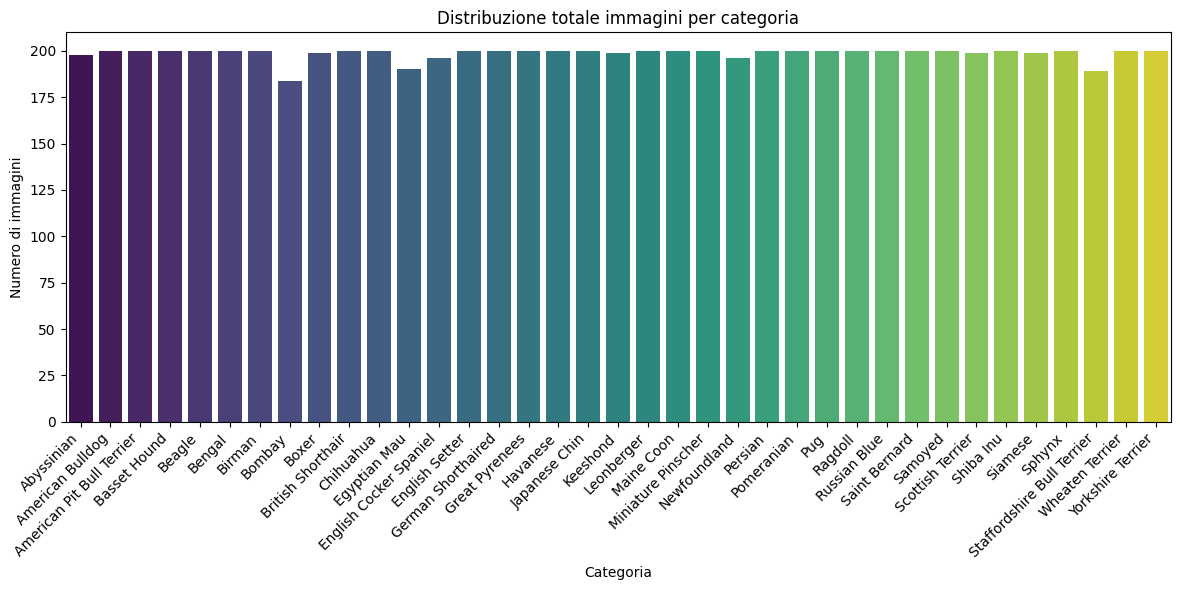

In [ ]:
# Codice originale senza output
# ...

La distribuzione è abbastanza uniforme, alcune classi hanno alcune foto in meno ma nello stesso ordine di grandezza. Valutiamo esempi di immagini.
I dati non sono molto numerosi per cui procederemo alla creazione di immagini sintetiche da poter aggiungere al dataset.

In [ ]:
def back_to_img(img):
    """
    funzione per mostrare l'immagine originale come prima delle trasformazioni
    :param img: immagine da convertire
    :return: immagine convertita
    """
    np_img=img.numpy()
    return np.transpose(np_img,(1,2,0)) #trasformiamo

In [ ]:
plt.imshow(back_to_img(oxford_dataset[3][0]))
plt.title(oxford_dataset.classes[oxford_dataset[10][1]])
plt.show()

Si tratta di un'immagine di un gatto di razza Abyssinia, l'animale è in primo piano, a parte lo sfondo non notiamo rumore particolare o oggetti estranei. Analizziamo anche altri elementi/categorie.

In [ ]:
def show_sample(dataset,iteration):
  """
  funzione che mostra esempi delle immagini presneti del dataset a partire da un certo indice.
  :param dataset: dataset da valutare
  :param iteration: indice da cui iniziare a visualizzare
  """
  num_row=2
  num_col=5
  fig,  axes = plt.subplots(num_row, num_col, figsize=(1.5*num_col, 2*num_row))
  for i in range(num_row*num_col):
    ax=axes[i//num_col,i%num_col]
    ax.imshow(back_to_img(dataset[iteration*num_row*num_col+i][0]))
    ax.set_title(dataset.classes[dataset[iteration*num_row*num_col+i][1]])
    ax.axis('off')
  plt.tight_layout()
  plt.show()

In [ ]:
show_sample(oxford_dataset,0)

In [ ]:
show_sample(oxford_dataset,100)

In [ ]:
show_sample(oxford_dataset,200)

In [ ]:
show_sample(oxford_dataset,300)

In generale gli animali domestici sono in primo piano, alcune volte inquadrati integralmente altre col solo volto, c'è uno sfondo variagato, ma non sono solitamente presenti molti oggetti che potrebbero distrarre l'attenzione della rete. Alcune volte le immagini sono tagliate dalla trasformazione che normalizza le dimensioni delle delle immagini e questa trasformazione a volte esclude parte del muso dell'animale e questo potrebbe creare difficoltà.


##Generazione nuove immagini

###Generazione Caption

Innanzitutto dobbiamo assegnare una descrizione testuale alle immagini attualmente presenti nel dataset. E' stato scelto ol modello **blip-image-captioning-base** di *salesForce* da Hugging Face che ha solitamente buone prestazioni con animali.

Scarichiamo il modello.


In [ ]:
# modello blip-image-captioning-base
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

model.to(device)

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-0

Per il captioning devo avere le immagini senza trasformazioni.

In [ ]:
dataset_notransform = torchvision.datasets.OxfordIIITPet(root='./data', split='trainval', download=True, transform=None)

100%|██████████| 792M/792M [00:06<00:00, 113MB/s] 
100%|██████████| 19.2M/19.2M [00:00<00:00, 113MB/s] 


Genero le caption per le immagini del training set.

In [ ]:
captions = []
batch_size = 8 # Definisco la dimensione del batch

for i in tqdm(range(0, len(dataset_notransform), batch_size), desc="Generazione Caption"):
    batch_images = []
    batch_labels = []
    batch_indices = []

    # Prepara il batch di immagini e label
    for j in range(batch_size):
        current_index = i + j
        if current_index < len(dataset_notransform):
            image, label = dataset_notransform[current_index]
            batch_images.append(image)
            batch_labels.append(label)
            batch_indices.append(current_index)

    inputs = processor(images=batch_images, return_tensors="pt").to(device)
    out = model.generate(**inputs, max_new_tokens=30)

    # Decodifica le caption
    for k, generated_caption_tokens in enumerate(out):
        caption = processor.decode(generated_caption_tokens, skip_special_tokens=True)
        captions.append({
            "index": batch_indices[k],
            "label": batch_labels[k],
            "caption": caption
        })

    if i % 80 == 0:
        print("\n", i, caption)


Generazione Caption:   0%|          | 0/460 [00:00<?, ?it/s]


 0 a cat sitting on the floor

 80 a dog laying in the grass

 160 a dog on a deck

 240 a dog with a collar

 320 a cat with blue eyes

 400 a dog standing in the snow

 480 a cat laying on a rock

 560 a cat sitting on a chair

 640 a dog laying on the ground

 720 a dog sitting in the grass

 800 a dog laying in the grass

 880 a dog sitting on the floor

 960 a dog on the beach

 1040 a dog laying on a deck

 1120 a fluffy brown dog

 1200 a dog sitting in the grass

 1280 a small dog with a pink banda

 1360 a cat laying in the grass

 1440 a dog standing on a bench

 1520 a black dog sitting on the floor

 1600 a cat sitting in the grass

 1680 a cat sitting on a white pillow

 1760 a shaggyed dog standing in the grass

 1840 a cat sleeping on a white blanket

 1920 a dog with a blue collar

 2000 a dog with a red collar

 2080 a dog laying on the grass

 2160 a cat with blue eyes

 2240 a dog is looking at a person

 2320 a cat with a bush in its mouth

 2400 a cat with yellow 

Salvo le caption generate.

In [ ]:
filename_captions = '/content/drive/MyDrive/datasets/oxford_pet/captions.pkl'

In [ ]:
#dump captions on google drive
with open(filename_captions, 'wb') as f:
    pickle.dump(captions, f)


In [ ]:
#load captions by google drive
with open(filename_captions, 'rb') as f:
    captions = pickle.load(f)

###Generazione Varianti


Ora devo generare delle varianti delle caption.

Per questo compito è stato scelto il modello **Ashishkr/Gpt2-paraphrase_generation** che è in grado di creare un numero di parafrasi a scelta da un testo di partenza anche breve come le nostre caption.

In [ ]:
model_name= "Ashishkr/Gpt2-paraphrase_generation"

tokenizer = AutoTokenizer.from_pretrained("Ashishkr/Gpt2-paraphrase_generation")
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained("Ashishkr/Gpt2-paraphrase_generation")

model.to(device)

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: Ashishkr/Gpt2-paraphrase_generation
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED |  | 
transformer.h.{0...23}.attn.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1024)
    (wpe): Embedding(1024, 1024)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3072, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=1024)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=4096, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=4096)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1024, out_features=50257, bias=False)
)

Definiamo il metodo per generare le varianti.

In [ ]:
def paraphrase(model, tokenizer,device, text, num_results=5):
    """
    metodo per produrre varianti di una caption
    :param model: modello da utilizzare
    :param tokenizer: tokenizer da utilizzare
    :param device: dispositivo su cui addestrare
    :param text: caption da modificare
    :param num_results: numero di varianti da produrre
    :return: lista di varianti della caption
    """
    query= text + " ~~ "

    # Calcolo input_ids e attention mask
    encoded_input = tokenizer(query.lower(), return_tensors='pt', padding=True, truncation=True).to(device)
    input_ids = encoded_input['input_ids']
    attention_mask = encoded_input['attention_mask']

    # Imposto il pad_token_id (non settato per modelli GPT-like)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    sample_outputs = model.generate(input_ids,
                                    attention_mask=attention_mask, # Passa l'attention_mask calcolata
                                    pad_token_id=tokenizer.pad_token_id, # Imposta il pad_token_id del tokenizer
                                    do_sample=True,
                                    num_beams=1,
                                    max_length=128,
                                    temperature=0.9,
                                    top_p= 0.99,
                                    top_k = 30,
                                    num_return_sequences=num_results)
    paraphrases = []
    for i in range(len(sample_outputs)):
        r = tokenizer.decode(sample_outputs[i], skip_special_tokens=True).split('||')[0]
        r = r.split(' ~~ ')[1]
        if r not in paraphrases:
            paraphrases.append(r)

    return paraphrases

Struttura attuale di caption:

In [ ]:
captions[0]

{'index': 0, 'label': 0, 'caption': 'a cat sitting in a bag'}

Testiamo la generaizone di varianti sul primo caption.

In [ ]:
test_genaration=paraphrase(model, tokenizer, device, captions[0]['caption'],num_results=3)
test_genaration

['      the other one  is the cat who s in the bag  ',
 ' the cat was sitting in a sack  ',
 ' a cat sitting in a sack   ']

Generiamo ora le varianti per l'intero dataset.

In [ ]:
for i in tqdm(range(0, len(captions)), desc="Variazione caption"):

    caption = captions[i]["caption"]
    variations = paraphrase(model, tokenizer, device, caption,num_results=3)
    captions[i]["variations"] = variations

    if i % 100 == 0:
        print("\n", i, caption, "-->", variations)


Variazione caption:   0%|          | 0/3680 [00:00<?, ?it/s]


 0 a cat sitting in a bag --> [' a cat in a bag ', ' he has a cat in the bag  ', ' a cat sitting in a bag  ']

 100 a dog standing on the floor --> [' it s just a dog standing on the floor  ', ' a dog standing on the floor   ', ' dog on the floor ']

 200 a dog with a sad look --> [' a dog with a sad face  ', ' the dog with the sad  sad eyes   ']

 300 a cat laying on a blue blanket --> [' the cat     the cat     the cat   ', ' when the cat lies on the blue blanket ', ' the cat laying on the blue sheets   ']

 400 a dog with a white spot --> [' dog with white spot ', ' dog with black spots  ', ' is dog with a white stain  ']

 500 a small dog standing next to a red suitcase --> [' standing next to a red suitcase   ', '  small dog standing next to red suitcase  ', ' the small dog stood beside a redcase  ']

 600 a dog sitting in the grass near a pond --> [' a dog sits in the grass near the pond   ', ' the dog  sits on grass by the pond  ', ' a dog sitting on a grass by the pond   ']

 

Salvo le variazioni ottenute.

In [ ]:
#dump captions
with open(filename_captions, 'wb') as f:
    pickle.dump(captions, f)


In [ ]:
#load captions
with open(filename_captions, 'rb') as f:
    captions = pickle.load(f)

Verifico il salvataggio delle varianti.

In [ ]:
captions[0]

{'index': 0,
 'label': 0,
 'caption': 'a cat sitting in a bag',
 'variations': [' a cat in a bag ',
  ' he has a cat in the bag  ',
  ' a cat sitting in a bag  ']}

###Generazione Immagini dalle didascalie

Istanzio il modello per la generazione di immagini.  

In questo caso abbiamo scelto il modello **runwayml/stable-diffusion-v1-5** che può dare buone prestazioni nella generazioni di animali.

In [ ]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
).to(device)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Definiamo la funzione che usa la pipe istanziata.

In [ ]:
def generate_images(path, caption):
    """
    Metodo per generare immagini a partire da una caption
    :param path: percorso dove salvare l'immagine
    :param caption: caption da utilizzare per la generazione
    """
    image = pipe(caption).images[0]
    image.save(path)

Generiamo le immagini per tutte le caption ottenute selezionando randomicamente la caption o una delle sue varianti.

In [ ]:
for i in tqdm(range(0, len(captions)), desc="Generazione nuove immagini"):

    all_captions_for_image = list(captions[i]["variations"])
    all_captions_for_image.append(captions[i]['caption'])
    chosen_caption_text = random.choice(all_captions_for_image)

    label_id = captions[i]['label']
    label_name = oxford_dataset.classes[label_id]

    # Costruisco un prompt per lo Stable Diffusion
    prompt_caption = "a realistic photo of " + chosen_caption_text + ", high detail"
    prompt_caption = prompt_caption.replace("dog", label_name + " dog")
    prompt_caption = prompt_caption.replace("cat", label_name + " cat")
    prompt_caption = prompt_caption.replace("kitten", label_name + " kitten")

    filename_dir = os.path.join('/content/drive/MyDrive/datasets/oxford_pet/generated/',label_name)
    filename_base = str(label_id) + '_' + str(i) + '.png'

    filename_full_path = os.path.join(filename_dir, filename_base)
    if not os.path.exists(os.path.dirname(filename_full_path)):
       os.makedirs(os.path.dirname(filename_full_path))

    # Genero le immagini
    generate_images(filename_full_path, prompt_caption)

Valutiamo le immagini generate tramite alcuni esempi.

In [ ]:
def show_sample_generated_img(class_name):
    """
    Funzione per mostrare immagini generate
    :param class_name: nome della categoria
    """
    num_row = 2
    num_col = 5
    fig, axes = plt.subplots(num_row, num_col, figsize=(3*num_col, 3*num_row))

    # ricostruiamo il path della directory
    class_dir = os.path.join('/content/drive/MyDrive/datasets/oxford_pet/generated/', class_name)

    #recuperiamo le immagini
    image_files = [f for f in os.listdir(class_dir) if f.endswith('.png') or f.endswith('.jpg')]

    # Scegliamo quelle da visualizzare
    if len(image_files) < num_row * num_col:
        images_to_display = image_files
    else:
        images_to_display = random.sample(image_files, num_row * num_col)

    for i, img_filename in enumerate(images_to_display):
        ax = axes[i // num_col, i % num_col]
        img_path = os.path.join(class_dir, img_filename)
        img = Image.open(img_path)

        ax.imshow(img)
        ax.set_title(class_name+"\n"+img_filename)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
for class_name in dataset_notransform.classes:
    show_sample_generated_img(class_name)

In generale le immagini sono state ben generate ma ci sono alcuni intrusi, forse in questi casi la parafrasi ha omesso che nella foto fosse presente un animale o il tipo di animale. Alcune foto sono risultate completamente nere per i filtri NSFW.

Verifico alcuni casi...

In [ ]:
plt.imshow(back_to_img(oxford_dataset[1944][0]))
plt.title(oxford_dataset[1944][1])
plt.show()

Immagine originale

In [ ]:
captions[1944]

{'index': 1944,
 'label': 1,
 'caption': 'a black purse',
 'variations': [' black purse  ',
  ' a black handbag  ',
  '                black purse ']}

In questo caso anche la caption generica non contenenva indicazioni su un cane, ma solo sulla borsa su cui è appoggiato.

In [ ]:
plt.imshow(back_to_img(oxford_dataset[2219][0]))
plt.title(oxford_dataset[2219][1])
plt.show()

In [ ]:
captions[2219]

{'index': 2219,
 'label': 7,
 'caption': 'adopt a domestic domestic domestic domestic domestic domestic domestic domestic domestic domestic domestic domestic domestic domestic domestic domestic domestic domestic domestic',
 'variations': ['~~~ 1st part  ‘ and provides for the implementation of … … for the establishment of a national national  national domestic national  national national  national  national  national  ',
  ' cid131  ~~~ cen en iso 10991212002 agricultural machinery — safety requirements — part 1  general requirements  iso 109912002  ',
  '~~~  domestic  domestic  domestic domestic domestic domestic  domestic  domestic  domestic  domestic  ']}

Qui la caption originale era entrata in un loop generativo, quindi il modello di generazione delle caption ha fallito. forse per via che il gatto si perde un po' nello sfondo.

In [ ]:
plt.imshow(back_to_img(oxford_dataset[1943][0]))
plt.title(oxford_dataset[1943][1])
plt.show()

In [ ]:
captions[1943]

{'index': 1943,
 'label': 1,
 'caption': 'a man laying on the floor',
 'variations': [' a man lying on the floor   ',
  ' the one on the floor  ',
  '  man lying on the floor ']}

Qui la cation originale non conteneva cani o gatti. Si concentra sull'uomo alle spalle.

In [ ]:
plt.imshow(back_to_img(oxford_dataset[2967][0]))
plt.title(oxford_dataset[2967][1])
plt.show()

In [ ]:
captions[2967]

{'index': 2967,
 'label': 22,
 'caption': 'a brown bear sitting on a hill',
 'variations': [' brown bear sitting on a hillside   ',
  ' brown bear sits on top of hill ',
  ' the brown bear sitting on the hill  ']}

Qui l'animale è stato "scambiato" dal sistema di caption per un orso.

###Pulizia generazione

Cancello le immagini nere o in cui nessun caption risulta contenere cani o gatti.

In [ ]:
def claen_dataset(captions,dataset):
  """
   Funzione che cancella le immagini nere o in cui nessun caption risulta contenere cani o gatti.
   :param captions: lista di caption
   :param dataset: dataset da valutare
  """
  for i in range(len(captions)-1,-1,-1):
    #image path
    class_name = dataset.classes[captions[i]['label']]
    class_dir = os.path.join('/content/drive/MyDrive/datasets/oxford_pet/generated/', class_name)
    filename_base = str(captions[i]['label']) + '_' + str(i) + '.png'
    imageFile = os.path.join(class_dir, filename_base)

    delete_image = False

    # la caption non contiene parole chiave del dataset (cani o gatti) quindi la generazione potrebbe essere fuorviante
    if 'dog' not in captions[i]['caption'].lower() and 'cat' not in captions[i]['caption'].lower() and 'kitten' not in captions[i]['caption'].lower():
      delete_image = True

    # l'immagine è tutta nera quindi inutile per la data augmentation
    if os.path.exists(imageFile) and not delete_image:
      try:
        img = Image.open(imageFile)
        #immagine tutta nera
        if np.all(np.asarray(img) < 5):
          print(f"Deleting black image: {imageFile}")
          delete_image = True
      except Exception as e:
        print(f"Could not open image {imageFile}: {e}")
        delete_image = True # Considera immagini illegebili  come mal generate

    if delete_image and os.path.exists(imageFile):
        print(f"Deleting {imageFile}")
        os.remove(imageFile)

In [ ]:
claen_dataset(captions,dataset_notransform)

Valuto la distribuzione delle immagini rimanenti.

In [ ]:
data_dir = '/content/drive/MyDrive/datasets/oxford_pet/generated/'

totale=0

distribution={}

for category in os.listdir(data_dir):
   category_dir = os.path.join(data_dir, category)
   if os.path.isdir(category_dir):
      num_images = len(os.listdir(category_dir))
      totale= totale+num_images
      if category not in distribution:
         distribution[category]=0
      distribution[category]+=num_images

print("Ditribution",distribution)
print("Totale:",totale)

Ditribution {'Abyssinian': 99, 'American Bulldog': 91, 'American Pit Bull Terrier': 96, 'Basset Hound': 100, 'Beagle': 97, 'Bengal': 97, 'Birman': 98, 'Bombay': 94, 'Boxer': 95, 'British Shorthair': 99, 'Chihuahua': 94, 'Egyptian Mau': 91, 'English Cocker Spaniel': 93, 'English Setter': 97, 'German Shorthaired': 100, 'Great Pyrenees': 97, 'Havanese': 98, 'Japanese Chin': 98, 'Keeshond': 98, 'Leonberger': 94, 'Maine Coon': 100, 'Miniature Pinscher': 97, 'Newfoundland': 94, 'Persian': 100, 'Pomeranian': 97, 'Pug': 95, 'Ragdoll': 96, 'Russian Blue': 100, 'Saint Bernard': 98, 'Samoyed': 97, 'Scottish Terrier': 99, 'Shiba Inu': 90, 'Siamese': 96, 'Sphynx': 29, 'Staffordshire Bull Terrier': 100, 'Wheaten Terrier': 99, 'Yorkshire Terrier': 98}
Totale: 3511


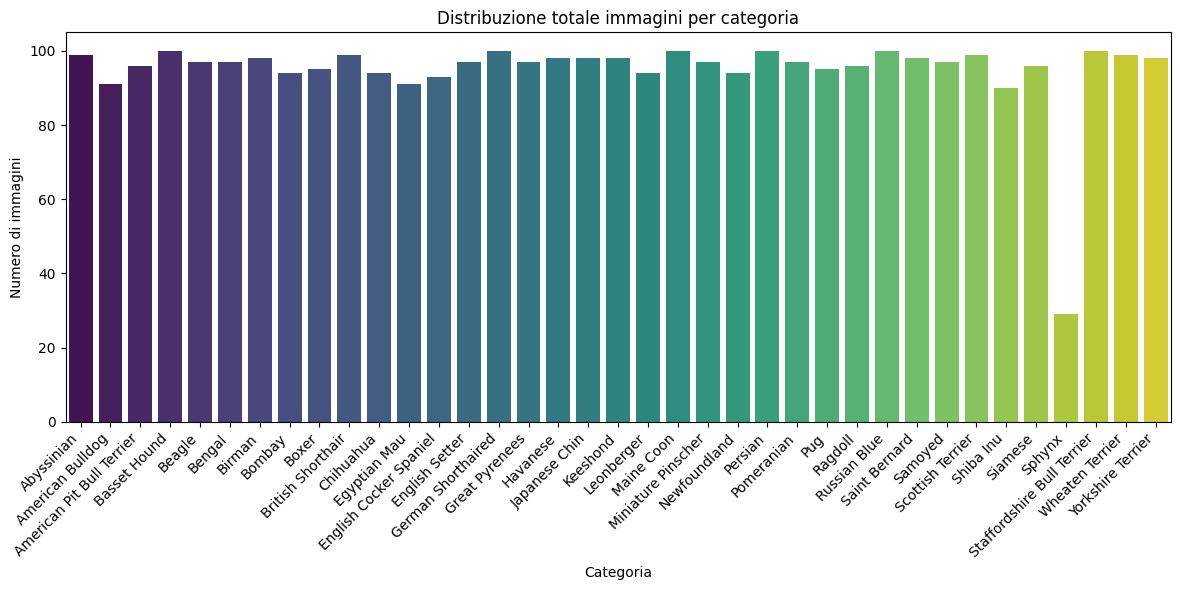

In [ ]:
plt.figure(figsize=(12, 6))
df_dist = pd.DataFrame(list(distribution.items()), columns=["category", "total"])
sns.barplot(x="category", y="total", data=df_dist, hue="category", palette="viridis",legend=False)

plt.title("Distribuzione totale immagini per categoria")
plt.xlabel("Categoria")
plt.ylabel("Numero di immagini")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In generale le generazioni sono abbastanzaq in linea col dataset originale, l'American Bulldog, l'Egyptin Mau, gli shiba Inu e gli Sphinx, soprattutto, sono le categorie in cui la generazione immagini ha fatto più fatica.  

Confronto immagini generate con quelle originali.

In [ ]:
def show_sample_generated_img_vs_original(class_name, num_results=3):
    """
    Funzione per mostrare immagini generate e originali
    :param class_name: nome della categoria
    """
    #path originale
    class_dir = os.path.join('/content/drive/MyDrive/datasets/oxford_pet/generated/', class_name)

    image_files = [f for f in os.listdir(class_dir) if f.endswith('.png') or f.endswith('.jpg')]

    # Scgeliamo l'immagine da mostrare
    if len(image_files) < num_results:
        images_to_display = image_files
    else:
        images_to_display = random.sample(image_files, num_results)

    # mostraimo a righe appiate le immagini corrispondenti
    fig, axes = plt.subplots(2, num_results, figsize=(4 * num_results, 8))

    for i, img_filename in enumerate(images_to_display):
        index = int(img_filename.replace('.png', '').split('_')[1])

        generated_img_path = os.path.join(class_dir, img_filename)
        generated_img = Image.open(generated_img_path)

        original_img_pil, _ = dataset_notransform[index]

        axes[0, i].imshow(generated_img)
        axes[0, i].set_title(f"Generated ({class_name})Index: {index}")
        axes[0, i].axis('off')

        axes[1, i].imshow(original_img_pil)
        axes[1, i].set_title(f"Original ({class_name}) Index: {index}")
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
for class_name in dataset_notransform.classes:
    show_sample_generated_img_vs_original(class_name)

Normalmente la generazione dà buoni risultati a parte alcuni casi in cui la sovrapposizione o la comprensenza di più oggetti mette in difficoltà la generazione delle immagini.

Valutiamo alcuni esempi problematici.

In [ ]:
captions[1682]

{'index': 1682,
 'label': 33,
 'caption': 'a cat sitting on a black couch',
 'variations': [' and a cat sitting on a black couch  ',
  ' cats sitting on black couches   ',
  ' sitting on the black sofa ']}

In questo caso il divano distre il modello.

In [ ]:
captions[3634]

{'index': 3634,
 'label': 36,
 'caption': 'a dog is sitting on a table with flowers',
 'variations': [' the dog sits on the table with the flowers   ',
  ' dog sits on a flower ',
  ' and you re sitting on a table with flowery flowers   ']}

Qui il mdoello disegna il ma non l'animale , forse è stata usata l'ultima caption in cui si è persa l'indicazione dell'animale.

In [ ]:
captions[3507]

{'index': 3507,
 'label': 33,
 'caption': 'a sphy cat',
 'variations': [' michal spchobotská 2  ', ' e  a swooning  ', ' s ']}

In questo caso il mdoello di parafrasi ha avuto molte difficoltà e generato testo non corrispondente.

Provo ad aggiungere qualche immagine per la categoria Sphynx senza usare caption generate, cercando di aggirare i filtri NSFW.

Gli sphynx, infatti, vengono in quanto gatti senza pelo vengono facilmente classificati come “nudity” dal filtro NSFW dei modelli di generazione immagini, anche se non c’è nulla di esplicito. proviamo a specificare meglio il prompt.

In [ ]:
for i in tqdm(range(0, len(captions)), desc="Generazione nuove immagini"):

    chosen_caption_text = captions[i]['caption']
    label_id = captions[i]['label']
    label_name = oxford_dataset.classes[label_id]

    if (label_name == 'Sphynx'):

        prompt_caption = "a realistic photo of " + chosen_caption_text + ", high detail"
        prompt_caption = prompt_caption.replace("dog", label_name + " dog")
        prompt_caption = prompt_caption.replace("cat", "hairless breed of domestic cat")
        prompt_caption = prompt_caption.replace("kitten", label_name + " kitten")
        prompt_caption = prompt_caption.replace("laying", "staying")
        prompt_caption = prompt_caption.replace("blanket", "grass")


        print(prompt_caption)

        filename_dir = os.path.join('/content/drive/MyDrive/datasets/oxford_pet/generated/',label_name)
        filename_base = str(label_id) + '_' + str(i) + '.png'

        filename_full_path = os.path.join(filename_dir, filename_base)

        if not os.path.exists(os.path.dirname(filename_full_path)):
          os.makedirs(os.path.dirname(filename_full_path))

        generate_images(filename_full_path, prompt_caption)

Modificando il prompt siamo riusciti ad ottenere alcune immagini migliori. Puliamo comunque quelle nere.

In [ ]:
claen_dataset(captions,dataset_notransform)

In [ ]:
show_sample_generated_img_vs_original("Sphynx")

Rivalutiamo la distribuzione finale dopo la generazione degli Sphynx.

In [ ]:
data_dir = '/content/drive/MyDrive/datasets/oxford_pet/generated/'

totale=0

distribution={}

for category in os.listdir(data_dir):
   category_dir = os.path.join(data_dir, category)
   if os.path.isdir(category_dir):
      num_images = len(os.listdir(category_dir))
      totale= totale+num_images
      if category not in distribution:
         distribution[category]=0
      distribution[category]+=num_images

print("Ditribution",distribution)
print("Totale:",totale)

Ditribution {'Abyssinian': 99, 'American Bulldog': 91, 'American Pit Bull Terrier': 96, 'Basset Hound': 100, 'Beagle': 97, 'Bengal': 97, 'Birman': 98, 'Bombay': 94, 'Boxer': 95, 'British Shorthair': 99, 'Chihuahua': 94, 'Egyptian Mau': 91, 'English Cocker Spaniel': 93, 'English Setter': 97, 'German Shorthaired': 100, 'Great Pyrenees': 97, 'Havanese': 98, 'Japanese Chin': 98, 'Keeshond': 98, 'Leonberger': 94, 'Maine Coon': 100, 'Miniature Pinscher': 97, 'Newfoundland': 94, 'Persian': 100, 'Pomeranian': 97, 'Pug': 95, 'Ragdoll': 96, 'Russian Blue': 100, 'Saint Bernard': 98, 'Samoyed': 97, 'Scottish Terrier': 99, 'Shiba Inu': 90, 'Siamese': 96, 'Sphynx': 60, 'Staffordshire Bull Terrier': 100, 'Wheaten Terrier': 99, 'Yorkshire Terrier': 98}
Totale: 3542


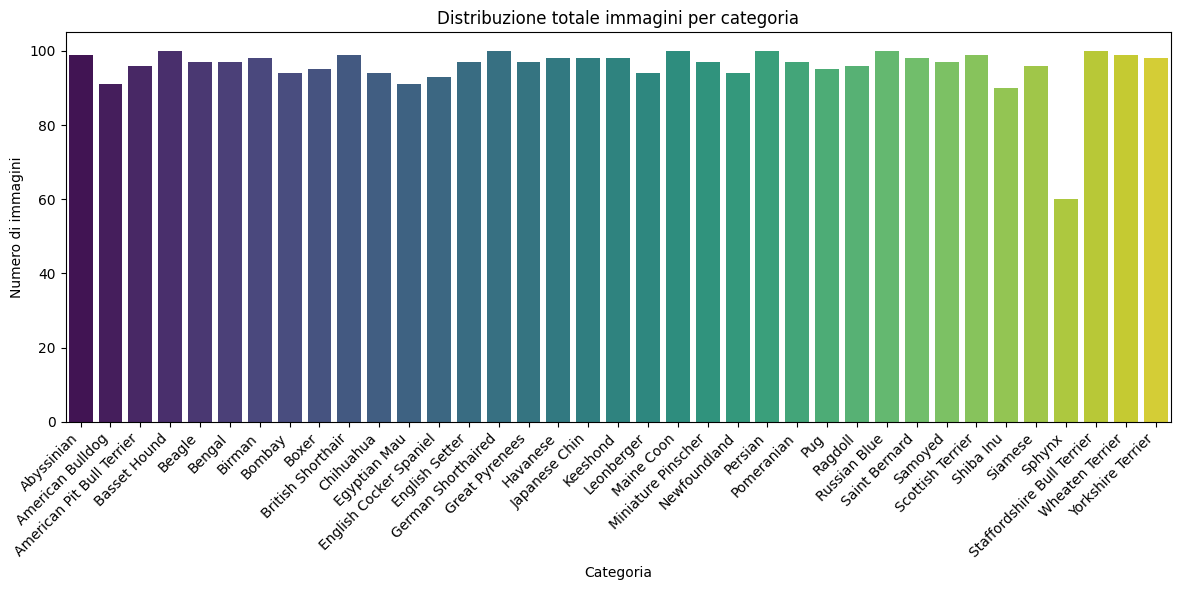

In [ ]:
plt.figure(figsize=(12, 6))
df_dist = pd.DataFrame(list(distribution.items()), columns=["category", "total"])
sns.barplot(x="category", y="total", data=df_dist, hue="category", palette="viridis",legend=False)

plt.title("Distribuzione totale immagini per categoria")
plt.xlabel("Categoria")
plt.ylabel("Numero di immagini")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Gli Sphynx sono migliorati anche se rimangono meno rappresentati di altre classi.

##Classificazione

Procediamo ora a verificare se la data augmentation permette un miglioramento della classificazione rispetto al dataset originale.

Predisponiamo una trasformazione base per Efficent.net

In [ ]:
transformTransfer= transforms.Compose([
        transforms.Resize(240),
        transforms.CenterCrop(240),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225]), # normalizzazione standard per image.net
       ])

Ricreiamo i dataset.

In [ ]:
# Load the dataset
oxford_dataset = torchvision.datasets.OxfordIIITPet(root='./data', split='trainval', download=True, transform=transformTransfer)
oxford_dataset_test = torchvision.datasets.OxfordIIITPet(root='./data', split='test', download=True, transform=transformTransfer)

### Split del dataset in Training e Validation

Suddividiamo il dataset di addestramento in due parti: una per l'addestramento vero e proprio del modello e una per la validazione. Questo ci permetterà di monitorare le performance del modello su dati non visti durante l'addestramento e di prevenire l'overfitting.

In [ ]:
train_size = int(0.8 * len(oxford_dataset))
val_size = len(oxford_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(oxford_dataset, [train_size, val_size])

In [ ]:
test_dataset = torchvision.datasets.OxfordIIITPet(root='./data', split='test', download=True, transform=transform)

Definiamo il batch size e carichiamo i dataset nei data loader che ci saranno utili per l'addestramento.

In [ ]:
batch_size=64

In [ ]:
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2,pin_memory=True)
valloader= torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2,pin_memory=True)
testloader= torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2,pin_memory=True)

Aggiungiamo le immagini generate al train dataset.

In [ ]:
oxford_dataset_generated = torchvision.datasets.ImageFolder(root='/content/drive/MyDrive/datasets/oxford_pet/generated/', transform=transformTransfer)

# Combiniamo insieme i dataset
train_dataset_augmented = torch.utils.data.ConcatDataset([train_dataset, oxford_dataset_generated])

# Creo un data loader per il train set aumentato
trainloader_augmented = torch.utils.data.DataLoader(train_dataset_augmented, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

Creiamo la directory di base contenere i risultati dei nostri training

In [ ]:
basedir='/content/drive/MyDrive/datasets/oxford_pet/results/'

os.makedirs(basedir, exist_ok=True)

Classi e funzioni utili all'addestramento.

In [ ]:
class EarlyStopping():
  """
   Classe per l'early stopping durante l'addestramento.
  """
  def __init__(self,save_path,min_delta,patience=5):
    """
    inizializzazione della classe
    """
    self.patience=patience
    self.min_delta=min_delta
    self.counter=0
    self.best_loss=None
    self.save_path=save_path
    self.early_stop = False

  def __call__(self,val_loss,model):
    """
    metodo principale per l'early stopping
    :param val_loss: loss di validation
    :param model: modello da salvare
    """
    if self.best_loss==None:
      self.best_loss=val_loss
      self.save_checkpoint(val_loss,model)
    elif self.best_loss-val_loss>self.min_delta:
      self.best_loss=val_loss
      self.save_checkpoint(val_loss,model)
      self.counter=0
    else:
      self.counter+=1
      if self.counter>=self.patience:
         self.early_stop=True

  def save_checkpoint(self,val_loss,model):
    """
    salvataggio del modello in caso di miglioramento della loss
    :param val_loss: loss di validation
    :param model: modello da salvare
    """
    if self.save_path is not None:
      # Create directory if it doesn't exist
      os.makedirs(os.path.dirname(self.save_path), exist_ok=True)
      torch.save(model.state_dict(),self.save_path)
      print(f"Model saved to {self.save_path}")

In [ ]:
def train_epoch(name,model,trainloader,criterion,optimizer,device,scaler):
  """
      Funzione che esegue un ciclo di addestramento per una epoca.
      :param name: nome dell'epoca
      :param model: modello da addestrare
      :param trainloader: dataloader di addestramento
      :param criterion: funzione di costo
      :param optimizer: ottimizzatore
      :param device: dispositivo su cui addestrare
      :param scaler: scaler per la normalizzazione
      :return: loss di addestramento
  """
  model.train()
  train_loss=0
  processed=0

  progress_bar = tqdm(trainloader, desc="Training epoch "+name, unit="batch")

  for i, data in enumerate(trainloader,0):
    images,labels=data[0].to(device),data[1].to(device)
    optimizer.zero_grad()

    if scaler is not None:
      with autocast(device.type, enabled=True): # Explicitly enable autocast
        output=model(images)
        loss=criterion(output,labels)

      scaler.scale(loss).backward()
      scaler.step(optimizer)
      scaler.update() # Keep update as it is standard practice

    else:
      output=model(images)
      loss=criterion(output,labels)
      loss.backward()
      optimizer.step()

    train_loss+=loss.item()
    processed+=len(images)

    progress_bar.set_postfix({'Loss': f'{train_loss/processed:.4f}'})

    progress_bar.update(1)

  return train_loss/processed

In [ ]:
def test_epoch(name,model, testloader, criterion, device):
    """
      Funzione che testa il modello su un set di dati specificato.
      :param name: nome dell'epoca
      :param model: modello da testare
      :param testloader: dataloader del set di dati da testare
      :param criterion: funzione di costo
      :param device: dispositivo su cui testare
      :return: loss e accuracy
    """
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(testloader, desc="Testing epoch "+name, unit="batch")

    with torch.no_grad():
        for i, data in enumerate(testloader,0):
            images,labels=data[0].to(device),data[1].to(device)
            output = model(images)
            loss = criterion(output, labels)
            test_loss += loss.item() * labels.size(0)  # somma ponderata
            _, predicted = torch.max(output, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            progress_bar.set_postfix({'Loss': f'{test_loss / total:.4f}', 'Accuracy': f'{correct / total:.4f}'})

            progress_bar.update(1)

    return test_loss / total, correct / total

In [ ]:
def train(model,trainloader,testloader,criterion,optimizer,epochs,device,early_stopping=None,scheduler=None):
  """
    Funzione che esegue l'addestramento della rete.
    :param model: modello da addestrare
    :param trainloader: dataloader di addestramento
    :param testloader: dataloader di test
    :param criterion: funzione di costo
    :param optimizer: ottimizzatore
    :param epochs: numero di epoche
    :param device: dispositivo su cui addestrare
    :param early_stopping: oggetto EarlyStopping per l'early stopping
    :param scheduler: scheduler per il learning rate
    :return: liste delle loss di addestramento e di test
  """

  train_loss_list=[]
  test_loss_list=[]
  test_acc_list=[]
  scaler = GradScaler(device.type)
  for epoch in range(epochs):
    train_loss=train_epoch(str(epoch+1),model,trainloader,criterion,optimizer,device,scaler)
    if (scheduler is not None):
      scheduler.step();
    test_loss,test_acc=test_epoch(str(epoch+1),model,testloader,criterion,device)
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)
    test_acc_list.append(test_acc)
    print(f"Epoch {epoch+1}/{epochs}, Train loss: {train_loss:.4f}. Validation loss: {test_loss:.4f}, Validation accuracy: {test_acc:.4f}")
    if early_stopping is not None:
      early_stopping(test_loss,model)
      if early_stopping.early_stop:
        print("Early stopping")
        break
  return train_loss_list,test_loss_list,test_acc_list

In [ ]:
def plot_loss_acc(train_loss_list, test_loss_list, test_acc_list):
    """
    Funzione che plotta i grafici di loss e accuracy
    :param train_loss_list: lista delle loss di addestramento
    :param test_loss_list: lista delle loss di test
    :param test_acc_list: lista delle accuracy di test
    """

    early_stop_epoch = test_loss_list.index(min(test_loss_list))
    min_val_loss = test_loss_list[early_stop_epoch]

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # --- Grafico Loss ---
    axs[0].plot(train_loss_list, label="Train loss")
    axs[0].plot(test_loss_list, label="Validation loss")
    axs[0].axvline(x=early_stop_epoch, color='red', linestyle='--', label='Early stopping')
    axs[0].plot(early_stop_epoch, min_val_loss, 'ro')
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")
    axs[0].set_title("Loss during training")
    axs[0].legend()
    axs[0].grid(True)

    # --- Grafico Accuracy ---
    axs[1].plot(test_acc_list, label="Validation Accuracy", color='green')
    axs[1].axvline(x=early_stop_epoch, color='red', linestyle='--', label='Early stopping')
    axs[1].plot(early_stop_epoch, test_acc_list[early_stop_epoch], 'ro')
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Accuracy")
    axs[1].set_title("Validation Accuracy")
    axs[1].set_ylim(0, 1)
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_confusion_matrix(model,testloader,classes,device):
  """
   Funzione che plotta la matrice di confusione
   :param model: modello da testare
   :param testloader: dataloader del set di dati da testare
   :param classes: lista delle classi
  """
  model.eval()
  y_true=[]
  y_pred=[]
  with torch.no_grad():
    for i, data in enumerate(testloader,0):
      images,labels=data[0].to(device),data[1].to(device)
      output=model(images)
      _,predicted=torch.max(output.data,1)
      y_true.extend(labels.cpu().numpy())
      y_pred.extend(predicted.cpu().numpy())

  cm=confusion_matrix(y_true,y_pred)
  plt.figure(figsize=(10,10))
  sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=classes,yticklabels=classes)

In [ ]:
def save_history(logs, save_path_logs):
  """
   Funzione che salva la history del train
   :param logs: dizionario contenente i dati da salvare
   :param save_path_logs: percorso del file in cui salvare i dati
  """
  with open(save_path_logs, 'w') as f:
    json.dump(logs, f)

### Training senza i dati sintetici

In [ ]:
efficient = efficientnet_b1(weights=EfficientNet_B1_Weights.IMAGENET1K_V1)

# Freeza i primi layer
for param in efficient.features.parameters():
    param.requires_grad = False

# Sblocca gli ultimi blocchi (fine-tuning parziale)
for param in efficient.features[6:].parameters():
    param.requires_grad = True

In [ ]:
class EfficentClassifier(nn.Module):
  def __init__(self,trained_model,num_features, num_classes):
    super().__init__()
    self.features=trained_model.features
    self.pooling=nn.AdaptiveAvgPool2d((1,1))
    self.classifier=nn.Sequential(
        nn.Linear(num_features,num_classes)
    )

  def forward(self,x):
    x=self.features(x)
    x=self.pooling(x)
    x=torch.flatten(x,1)
    x=self.classifier(x)
    return x


Trovo il numero di features di ingresso e il numero di classi in uscita e creo la testa di classificazione.

In [ ]:
num_ftrs = efficient.classifier[1].in_features
num_ftrs

1280

In [ ]:
len(train_dataset.dataset.classes)

37

Istanzio la classe.

In [ ]:
efficent_classifier=EfficentClassifier(efficient,num_ftrs,len(train_dataset.dataset.classes)).to(device)

summary(efficent_classifier, (3, 256, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             864
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              SiLU-3         [-1, 32, 128, 128]               0
            Conv2d-4         [-1, 32, 128, 128]             288
       BatchNorm2d-5         [-1, 32, 128, 128]              64
              SiLU-6         [-1, 32, 128, 128]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12         [-1, 32, 128, 128]               0
           Conv2d-13         [-1, 16, 128, 128]             512
      BatchNorm2d-14         [-1, 16, 1

Preparo la directory di output del modello

In [ ]:
efficientBasedir=os.path.join(basedir,'efficentNet')
os.makedirs(efficientBasedir, exist_ok=True)

efficient_classifier_save_file=os.path.join(efficientBasedir,"model.pt")
efficient_classifier_save_log=os.path.join(efficientBasedir,"log.json")

Istanzio il numero massimo di epoche, la funzione Loss , l'optimizer, l'Early stopping e lo scheduler per variare il learning rate.

In [ ]:
epochs=100

torch.manual_seed(RANDOM_SEED) #per riprodurre i risultati
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.AdamW(
    filter(lambda p: p.requires_grad, efficent_classifier.parameters()),
    lr=2e-3,          # learning rate iniziale
    weight_decay=1e-4  # regolarizzazione
)
earlyStopping=EarlyStopping(efficient_classifier_save_file,min_delta=0.001,patience=5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

Procedo all'addestramento

In [ ]:
train_loss_list,val_loss_list,val_acc_list=train(efficent_classifier,trainloader,valloader,criterion,optimizer,epochs,device,earlyStopping,scheduler)

Salvo il modello e la storia dell'addestramento.

In [ ]:
history_efficient={'train_loss_list':train_loss_list,'val_loss_list':val_loss_list,'val_acc_list':val_acc_list}
save_history(history_efficient,efficient_classifier_save_log)

In [ ]:
efficent_classifier.load_state_dict(torch.load(efficient_classifier_save_file))
with open(efficient_classifier_save_log,"r") as f:
  history_efficient=json.load(f)

Valutiamo le curve di apprendimento e l'accuracy raggiunta sul validation set.

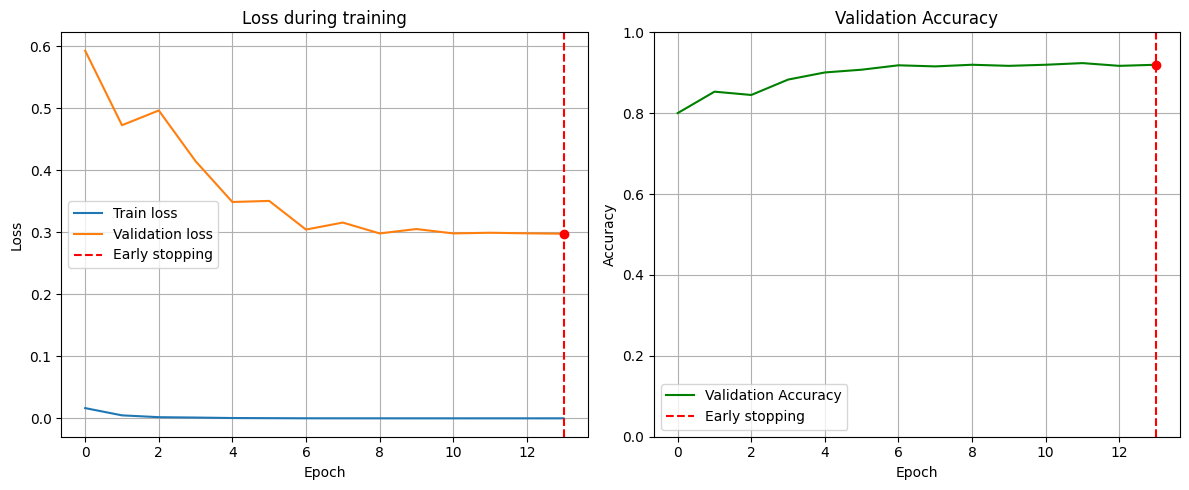

In [ ]:
plot_loss_acc(history_efficient["train_loss_list"],history_efficient["val_loss_list"],history_efficient["val_acc_list"])

Valuto le performance sul test set.

In [ ]:
test_loss,test_acc=test_epoch("test",efficent_classifier,testloader,criterion,device)
history_efficient["test_loss"]=test_loss
history_efficient["test_acc"]=test_acc
save_history(history_efficient,efficient_classifier_save_log)
print(f"Test loss: {test_loss:.4f}, test accuracy: {test_acc:.4f}")

Testing epoch test:   0%|          | 0/58 [00:00<?, ?batch/s]

Test loss: 0.8935, test accuracy: 0.7536


### Training Con i Dati sintetici

Istanzio una nuova rete da addestrare con l'aggiunta dei dati sintetici

In [ ]:
efficientBasedir_gen=os.path.join(basedir,'efficentNet_genertion')
os.makedirs(efficientBasedir_gen, exist_ok=True)

efficient_classifier_gen_save_file=os.path.join(efficientBasedir_gen,"model.pt")
efficient_classifier_gen_save_log=os.path.join(efficientBasedir_gen,"log.json")

In [ ]:
efficient_gen = efficientnet_b1(weights=EfficientNet_B1_Weights.IMAGENET1K_V1)

# Freeza i primi layer
for param in efficient_gen.features.parameters():
    param.requires_grad = False

# Sblocca gli ultimi blocchi (fine-tuning parziale)
for param in efficient_gen.features[6:].parameters():
    param.requires_grad = True

In [ ]:
efficent_classifier_gen=EfficentClassifier(efficient_gen,num_ftrs,len(train_dataset.dataset.classes)).to(device)

summary(efficent_classifier, (3, 256, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             864
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              SiLU-3         [-1, 32, 128, 128]               0
            Conv2d-4         [-1, 32, 128, 128]             288
       BatchNorm2d-5         [-1, 32, 128, 128]              64
              SiLU-6         [-1, 32, 128, 128]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12         [-1, 32, 128, 128]               0
           Conv2d-13         [-1, 16, 128, 128]             512
      BatchNorm2d-14         [-1, 16, 1

Istanzio il numero di epoche, la funzione Loss , l'optimizer, l'Early stopping e lo scheduler per variare il learning rate.

In [ ]:
epochs=100

torch.manual_seed(RANDOM_SEED) #per riprodurre i risultati
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.AdamW(
    filter(lambda p: p.requires_grad, efficent_classifier_gen.parameters()),
    lr=2e-3,          # learning rate iniziale
    weight_decay=1e-4  # regolarizzazione
)
earlyStopping=EarlyStopping(efficient_classifier_gen_save_file,min_delta=0.001,patience=5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

Procediamo col training.

In [ ]:
train_loss_list,val_loss_list,val_acc_list=train(efficent_classifier_gen,trainloader_augmented,valloader,criterion,optimizer,epochs,device,earlyStopping,scheduler)

Salvo il modello e la storia dell'addestramento.

In [ ]:
history_efficient_gen={'train_loss_list':train_loss_list,'val_loss_list':val_loss_list,'val_acc_list':val_acc_list}
save_history(history_efficient_gen,efficient_classifier_gen_save_log)

In [ ]:
efficent_classifier_gen.load_state_dict(torch.load(efficient_classifier_gen_save_file))
with open(efficient_classifier_gen_save_log,"r") as f:
  history_efficient_gen=json.load(f)

valutazione della soluzione

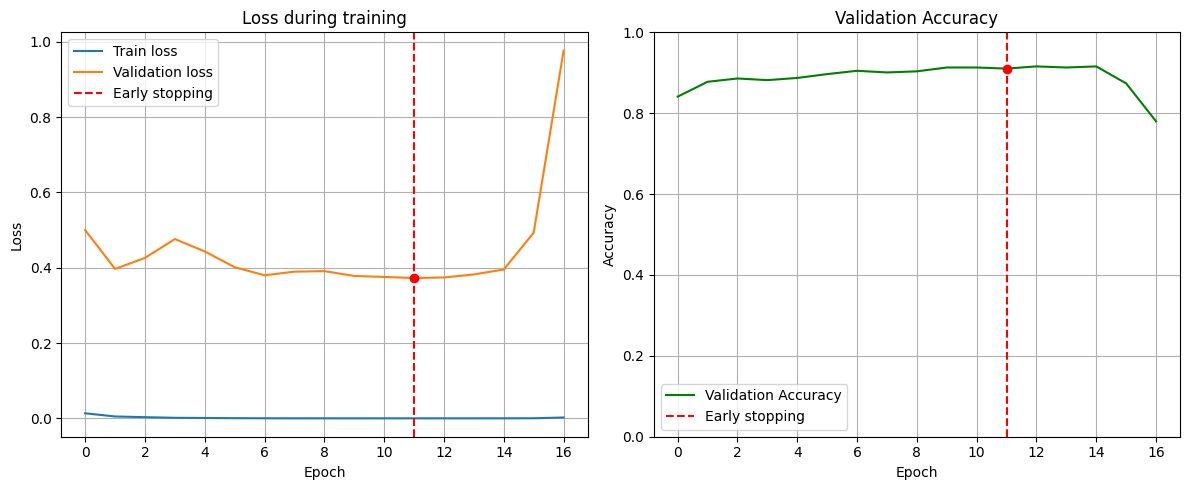

In [ ]:
plot_loss_acc(history_efficient_gen["train_loss_list"],history_efficient_gen["val_loss_list"],history_efficient_gen["val_acc_list"])

Valuto le performance sul test set.

In [ ]:
test_loss,test_acc=test_epoch("test",efficent_classifier_gen,testloader,criterion,device)
history_efficient_gen["test_loss"]=test_loss
history_efficient_gen["test_acc"]=test_acc
save_history(history_efficient_gen,efficient_classifier_gen_save_log)
print(f"Test loss: {test_loss:.4f}, test accuracy: {test_acc:.4f}")

Testing epoch test:   0%|          | 0/58 [00:00<?, ?batch/s]

Test loss: 0.8966, test accuracy: 0.7820


##Confronto

Confrontiamo l'addestratemento con e senza generazione.

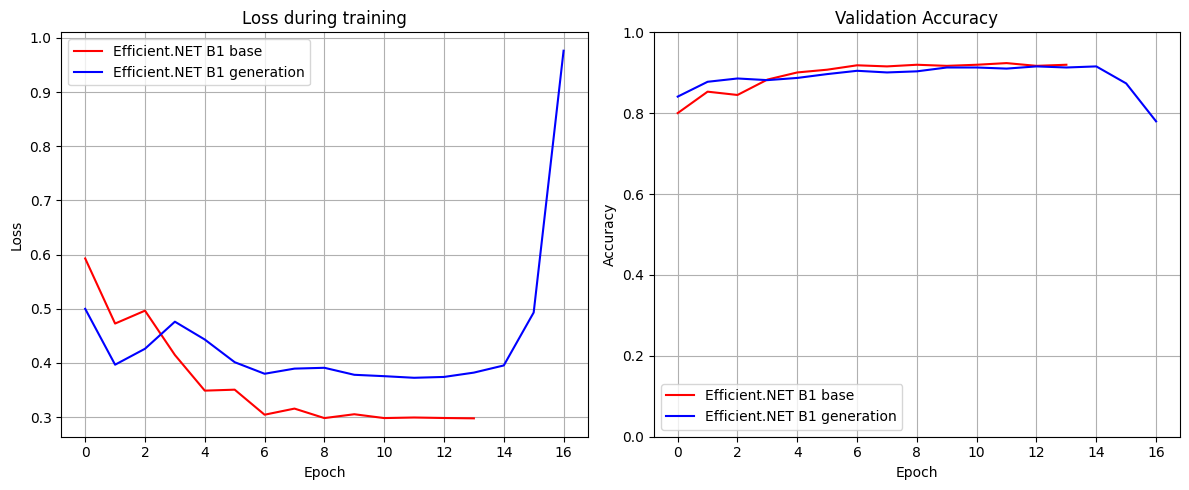

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --- Grafico Loss ---
axs[0].plot(history_efficient['val_loss_list'], label="Efficient.NET B1 base", color='red')
axs[0].plot(history_efficient_gen['val_loss_list'], label="Efficient.NET B1 generation", color='blue')
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].set_title("Loss during training")
axs[0].legend()
axs[0].grid(True)

# --- Grafico Accuracy ---
axs[1].plot(history_efficient['val_acc_list'], label="Efficient.NET B1 base", color='red')
axs[1].plot(history_efficient_gen['val_acc_list'], label="Efficient.NET B1 generation", color='blue')
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].set_title("Validation Accuracy")
axs[1].set_ylim(0, 1)
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

Confrontiamo ora le predizioni sul test set.

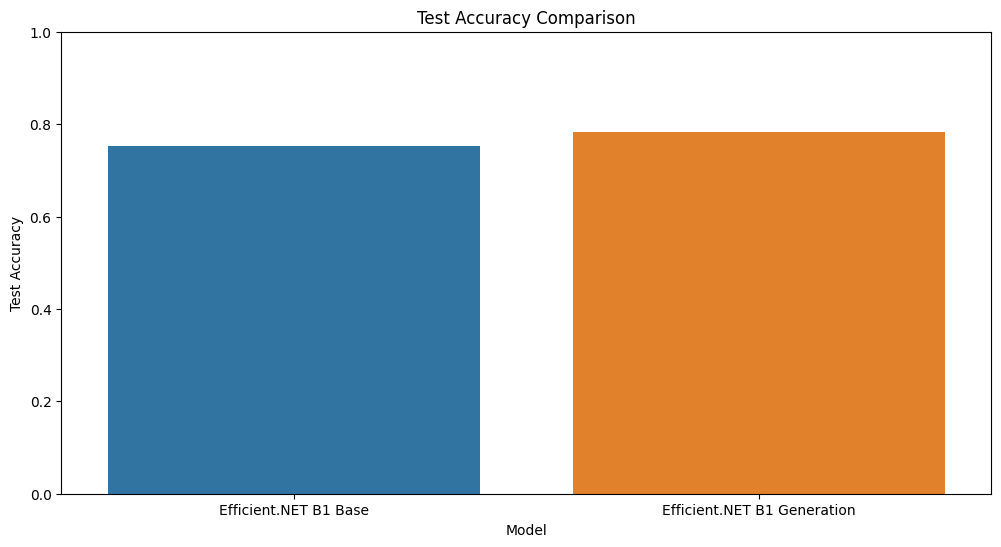

In [ ]:
fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(
    x=["Efficient.NET B1 Base", "Efficient.NET B1 Generation"],
    y=[history_efficient["test_acc"], history_efficient_gen["test_acc"]],
    ax=ax,
    hue=["Efficient.NET B1 Base", "Efficient.NET B1 Generation"],
    legend=False
)
ax.set_xlabel("Model")
ax.set_ylabel("Test Accuracy")
ax.set_title("Test Accuracy Comparison")
ax.set_ylim(0, 1)
plt.show()

### Classification Report senza dati sintetici

Studiamo il classification report e la matrice di confusione dei due modelli

In [ ]:
efficent_classifier.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = efficent_classifier(images)
        _, predicted = torch.max(outputs.data, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print("Classification Report per il modello base:")
print(classification_report(y_true, y_pred, target_names=train_dataset.dataset.classes))

Classification Report per il modello base:
                            precision    recall  f1-score   support

                Abyssinian       0.74      0.77      0.75        98
          American Bulldog       0.50      0.86      0.63       100
 American Pit Bull Terrier       0.48      0.64      0.55       100
              Basset Hound       0.98      0.57      0.72       100
                    Beagle       0.63      0.87      0.73       100
                    Bengal       0.79      0.62      0.70       100
                    Birman       0.84      0.73      0.78       100
                    Bombay       0.51      0.95      0.66        88
                     Boxer       0.90      0.54      0.67        99
         British Shorthair       0.81      0.80      0.80       100
                 Chihuahua       0.62      0.84      0.71       100
              Egyptian Mau       0.75      0.92      0.82        97
    English Cocker Spaniel       0.81      0.88      0.84       100
    

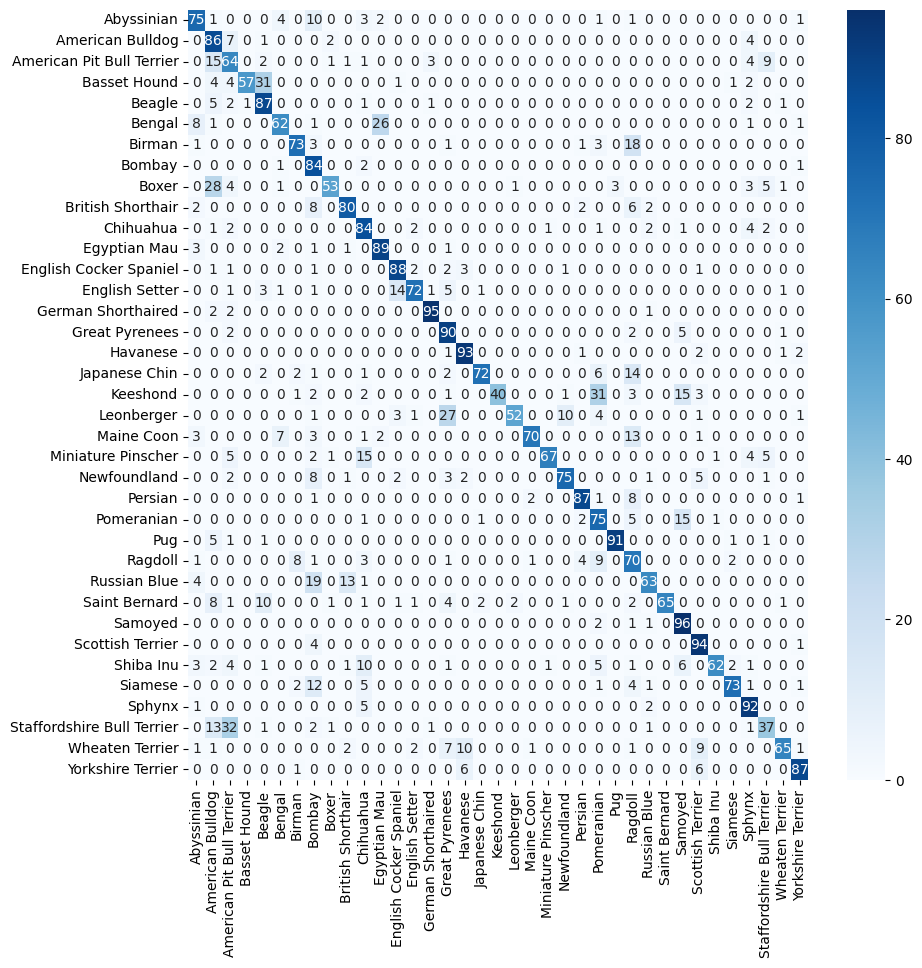

In [ ]:
plot_confusion_matrix(efficent_classifier,testloader,train_dataset.dataset.classes,device)

Alcune razze di animali rimangono molto simili nell'aspetto tra loro quindi sono facilmente confiondibili, come i vari tipi di Bull terrier e i BullDog coi Boxer.

### Classification Report con dati sintetici

Studiamo ora il classification report con la versione con data generation

In [ ]:
efficent_classifier_gen.eval()
y_true_gen = []
y_pred_gen = []

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = efficent_classifier_gen(images)
        _, predicted = torch.max(outputs.data, 1)
        y_true_gen.extend(labels.cpu().numpy())
        y_pred_gen.extend(predicted.cpu().numpy())

print("Classification Report per il modello con dati generati:")
print(classification_report(y_true_gen, y_pred_gen, target_names=train_dataset.dataset.classes))

Classification Report per il modello con dati generati:
                            precision    recall  f1-score   support

                Abyssinian       0.60      0.83      0.70        98
          American Bulldog       0.66      0.79      0.72       100
 American Pit Bull Terrier       0.46      0.63      0.53       100
              Basset Hound       0.87      0.78      0.82       100
                    Beagle       0.64      0.90      0.75       100
                    Bengal       0.62      0.62      0.62       100
                    Birman       0.70      0.82      0.76       100
                    Bombay       0.89      0.88      0.88        88
                     Boxer       0.93      0.57      0.70        99
         British Shorthair       0.75      0.80      0.78       100
                 Chihuahua       0.74      0.89      0.81       100
              Egyptian Mau       0.76      0.73      0.75        97
    English Cocker Spaniel       0.74      0.96      0.83  

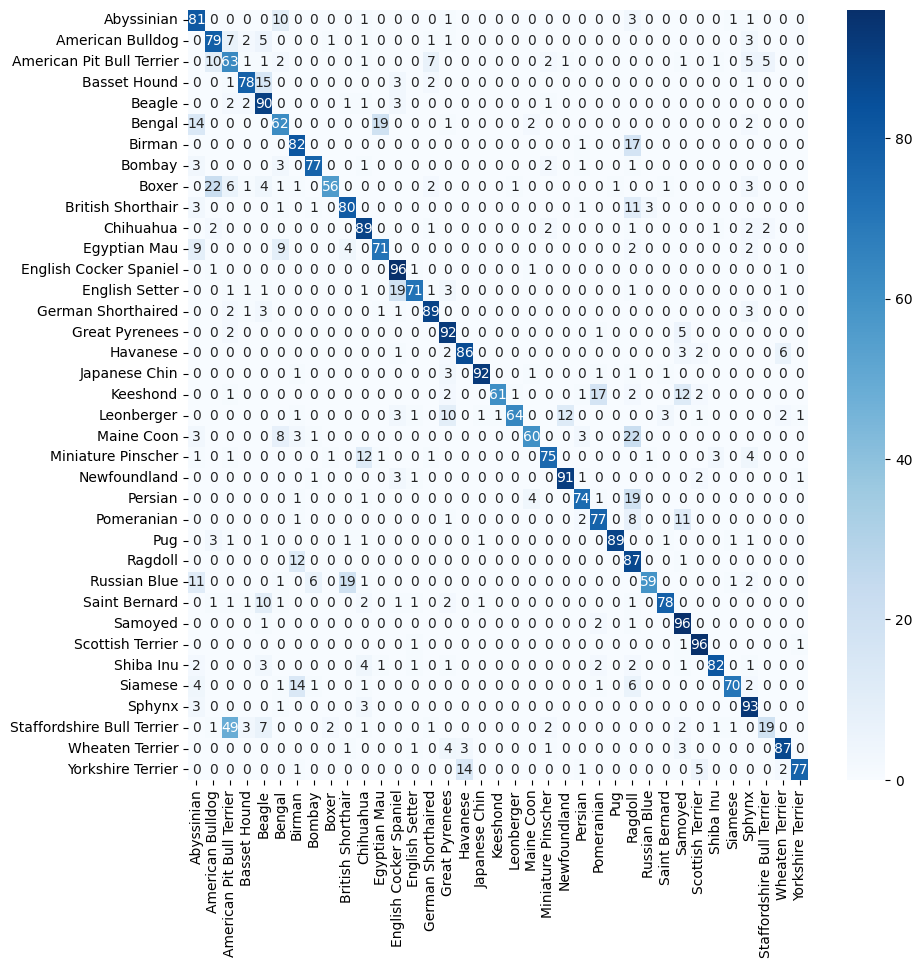

In [ ]:
plot_confusion_matrix(efficent_classifier_gen,testloader,train_dataset.dataset.classes,device)

Anche qui alcune razze di animali sono confuse tra loro, esempio, vari tipi di Bull terrier e i BullDog coi Boxer. Gli sphynx nonostante siano un po' sotto rappresentatnti performano bene, perchè evidentemente la mancanza di pelo e il colore rosato aiutano molto la rete nella loro individuazione.

##Conclusione

Tra i due modelli performa meglio quello con data augmentation generativa con accuracy superiore del 3%.

La generazione di immagini per aumentare il trainset può essere un'operazione chiave nel migliorare le performance della rete. Il punto delicato sta nell'individuazione di caption che descrivano correttamente le immagini e nel quanto parafrasare le didascalie generate: se si lascia troppa libertà al modello si rischia di generare poi dalla didascalia un'immagine diametralmente differente. In più, in alcuni casi, la presenza nel prompt di elementi accessori come fiori o divani può portare il mdoello a concentrarsi più su questi elementi "dimenticando" l'animale che è di fatto il focus del riconoscimento, mentre palline, erba o oggetti a fianco dell'animale non sembrano disturbare il modello generativo. Anche l'espressione dell'animale (triste...) in generale risulta abbastanza bene catturata anche se tende a sformare leggermente il muso dell'animale distorcendolo.

Punto di attenzione il filtro NSFW che può compromettere la generazione di intere categorie come abbiamo visto per i gatti Sphynx.